# Eniac: Discount Strategy Analysis

**Core question:** Is discounting beneficial for the company?

## Business questions
1. How many products are being discounted?
2. How big are the discounts as a percentage of product prices?
3. How do seasonality and special dates affect sales?
4. How should products be classified into categories?
5. What is the price distribution across categories?
6. How could data collection be improved?

> **Note on the data**
> The raw dataset was corrupted: malformed price formats, a `promo_price` column
> unusable in ~92% of rows, and inconsistencies between tables. The data quality
> phase is documented in a separate notebook. This analysis works with the cleaned
> result — roughly one third of the original product catalogue.

## 1. Loading the data

Four tables from Eniac's internal database:

| Table | Content |
|---|---|
| `orders` | one row per order |
| `orderlines` | one row per product within an order |
| `products` | product catalogue with list prices |
| `brands` | brand codes and names |

The files loaded here are the cleaned versions produced in the data quality phase.
Display options are set to show full decimal precision and up to 1,000 rows.

In [1]:
# Cleaned Data Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

url= "https://drive.google.com/file/d/1VEi18IH6hCB8USN7L5c2D6mDl3l7ljM2/view?usp=drive_link"
orderlines_path="https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orderinline_qu = pd.read_csv(orderlines_path)

url= "https://drive.google.com/file/d/1hKxIA34t5fB6chLGsh5_fUq3fTxO1xXO/view?usp=drive_link"
brands_path="https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_brands_qu = pd.read_csv(brands_path)

url= "https://drive.google.com/file/d/1qsssemPNVphBO-lDGQ980Lj5CYkfblxD/view?usp=sharing"
products_path="https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_products_qu = pd.read_csv(products_path)


url= "https://drive.google.com/file/d/1XamRkTccWzAyELHTfqWW-HnNfxILb1LD/view?usp=drive_link"
orders_path="https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orders_qu = pd.read_csv(orders_path)

## 2. First look

Checking row counts, column names, data types and missing values before starting.

In [2]:
df_brands_qu.info()
df_orderinline_qu.info()
df_orders_qu.info()
df_products_qu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  object 
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 2.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40985 entries, 0 to 40984
Data columns (total 4 columns):
 #   Column

## 3. Working copies

All further steps operate on copies, so the loaded data stays untouched
and can be compared against at any point.

In [3]:
orderlines = df_orderinline_qu.copy()
orders     = df_orders_qu.copy()
products   = df_products_qu.copy()
brands     = df_brands_qu.copy()

## 4. Type conversion

CSV files carry no type information, so date columns are read as plain text.
Converting them to `datetime` enables time-based filtering, resampling and plotting.

In [4]:
orders["created_date"] = pd.to_datetime(orders["created_date"])
orderlines["date"] = pd.to_datetime(orderlines["date"])

## 5. Time period and sales pattern

Two quick questions before the actual analysis: what period does the dataset cover,
and how do sales develop over time?

In [5]:
orderlines["date"].min(), orderlines["date"].max()

(Timestamp('2017-01-01 01:46:16'), Timestamp('2018-03-14 11:58:13'))

The data covers January 2017 to 14 March 2018.

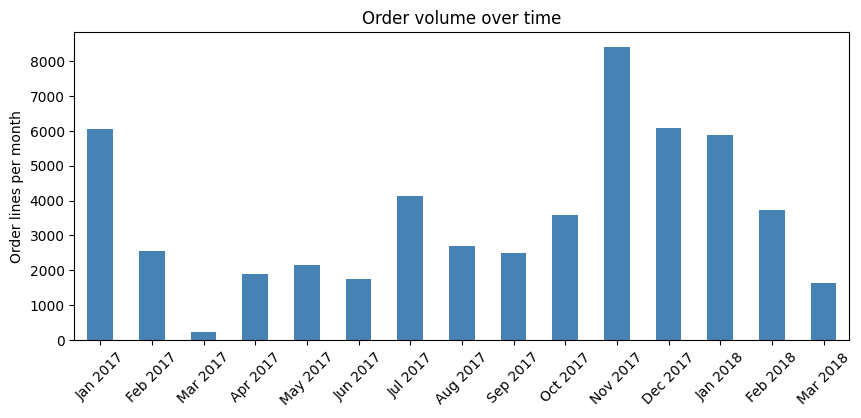

In [6]:
monthly_lines = orderlines.resample("ME", on="date").size()

plot_data = monthly_lines.copy()
plot_data.index = plot_data.index.strftime("%b %Y")

plot_data.plot(kind="bar", figsize=(10,4), color="steelblue")
plt.ylabel("Order lines per month")
plt.xlabel("")
plt.title("Order volume over time")
plt.xticks(rotation=45)
plt.show()

Two things stand out:

- a strong peak in **November 2017** — the busiest month by a wide margin
- an unexplained collapse in **February–March 2017**, examined in section X below

The first and last month are partial and not comparable to full months.

## 6. Building the analysis table

Discounts are not stored anywhere — they have to be derived.
`orderlines.unit_price` holds the price actually paid, `products.price` the list price.
Merging both tables on `sku` allows calculating the difference per sold item.

The product table also carries the categories created during the data quality phase.

In [7]:
analysis_df = orderlines.merge(
    products[["sku", "name", "price", "category"]],
    on="sku", how="inner"
)

analysis_df["discount"] = analysis_df["price"] - analysis_df["unit_price"]
analysis_df["discount_pct"] = analysis_df["discount"] / analysis_df["price"] * 100
analysis_df["line_revenue"] = analysis_df["unit_price"] * analysis_df["product_quantity"]

analysis_df.shape

(53231, 13)

## 7. How many products are being discounted?

Discount is defined as the difference between list price and price paid.
A threshold of 1% excludes rounding differences that are not actual discounts.

In [8]:
analysis_df["discounted"] = analysis_df["discount_pct"] > 1

analysis_df["discounted"].sum(), len(analysis_df), round(analysis_df["discounted"].mean() * 100, 1)

(np.int64(48734), 53231, np.float64(91.6))

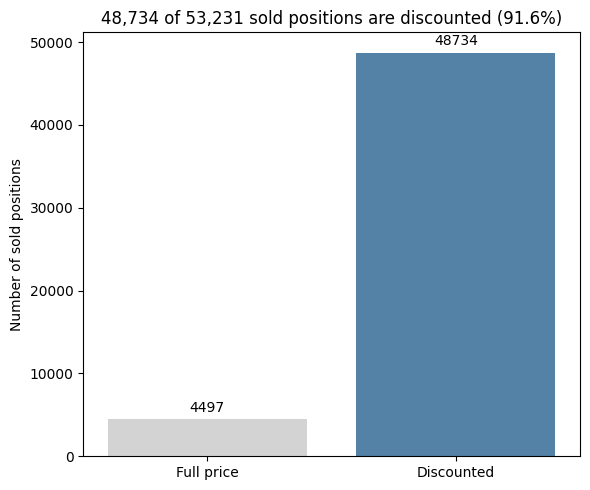

In [9]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=analysis_df, x="discounted", hue="discounted",
                   palette=["lightgray", "steelblue"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Full price", "Discounted"])
ax.set_xlabel("")
ax.set_ylabel("Number of sold positions")
ax.set_title("48,734 of 53,231 sold positions are discounted (91.6%)")
for c in ax.containers:
    ax.bar_label(c, fmt="%d", padding=3)
plt.tight_layout()
plt.show()

**Selling at a discount is Eniac's default, not a promotional exception.**

## 8. How big are the discounts?

Discounts are expressed as a percentage of the list price, so products
across different price levels stay comparable.

In [10]:
analysis_df["discount_pct"].describe()

,discount_pct
count,53231.00
mean,21.38
std,18.15
min,-212.27
25%,9.09
50%,17.65
75%,28.59
max,97.14


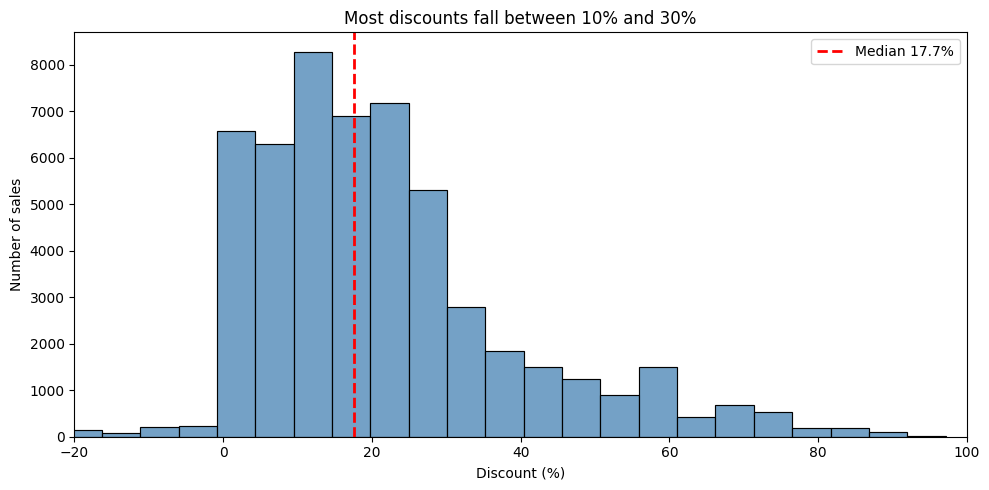

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(data=analysis_df, x="discount_pct", bins=60, color="steelblue")
plt.xlim(-20, 100)
plt.axvline(17.65, color="red", linestyle="--", linewidth=2, label="Median 17.7%")
plt.xlabel("Discount (%)")
plt.ylabel("Number of sales")
plt.title("Most discounts fall between 10% and 30%")
plt.legend()
plt.tight_layout()
plt.show()

- Median discount: **17.7%**
- Average discount: **21.4%**
- Half of all sales fall between 9% and 29%

Negative values occur where the list price was lowered after the sale —
`products.price` holds only the current value, with no price history.

**Eniac operates at a permanent ~20% below list price rather than running occasional promotions.**

## 9. How do seasonality and special dates affect sales?

The monthly view in section 5 showed a clear peak in November 2017.
Zooming into daily resolution shows whether this is driven by Black Friday.

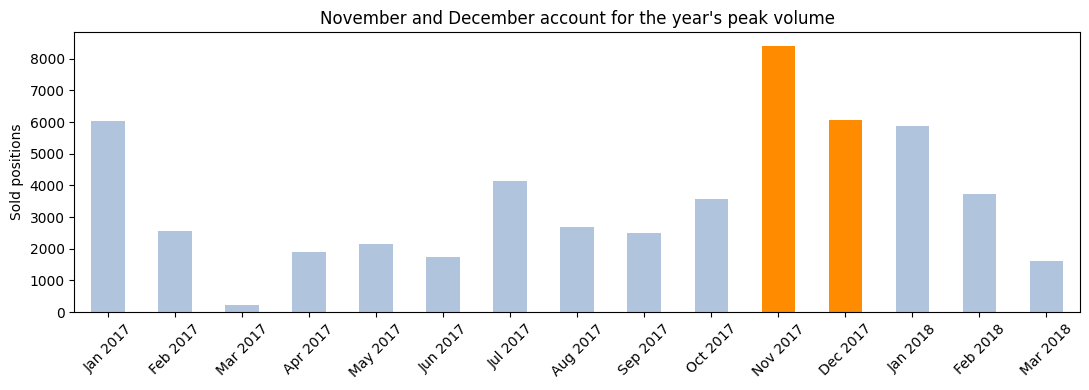

In [12]:
monthly = analysis_df.resample("ME", on="date").size()
plot_data = monthly.copy()
plot_data.index = plot_data.index.strftime("%b %Y")

farben = ["darkorange" if m in ["Nov 2017", "Dec 2017"] else "lightsteelblue"
          for m in plot_data.index]

plot_data.plot(kind="bar", figsize=(11,4), color=farben)
plt.ylabel("Sold positions")
plt.xlabel("")
plt.title("November and December account for the year's peak volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

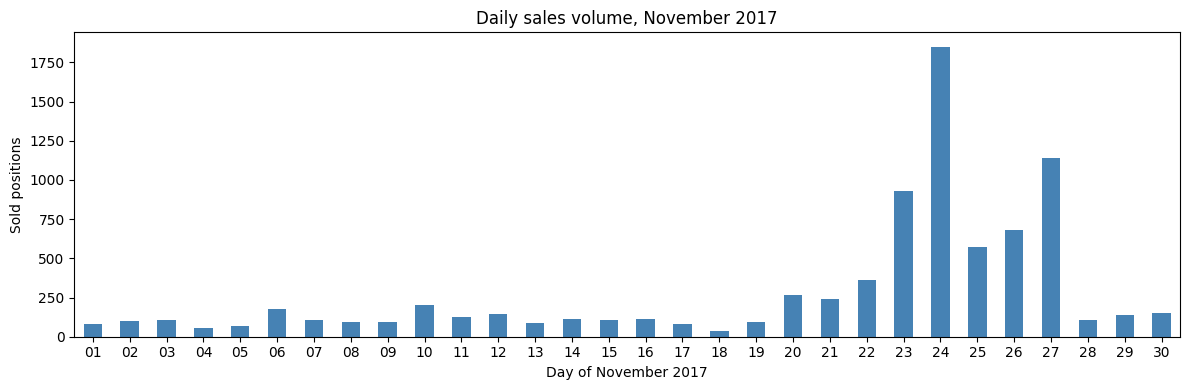

In [13]:
november = analysis_df.resample("D", on="date").size().loc["2017-11"]

november.index = november.index.strftime("%d")
november.plot(kind="bar", figsize=(12,4), color="steelblue")
plt.xlabel("Day of November 2017")
plt.ylabel("Sold positions")
plt.title("Daily sales volume, November 2017")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

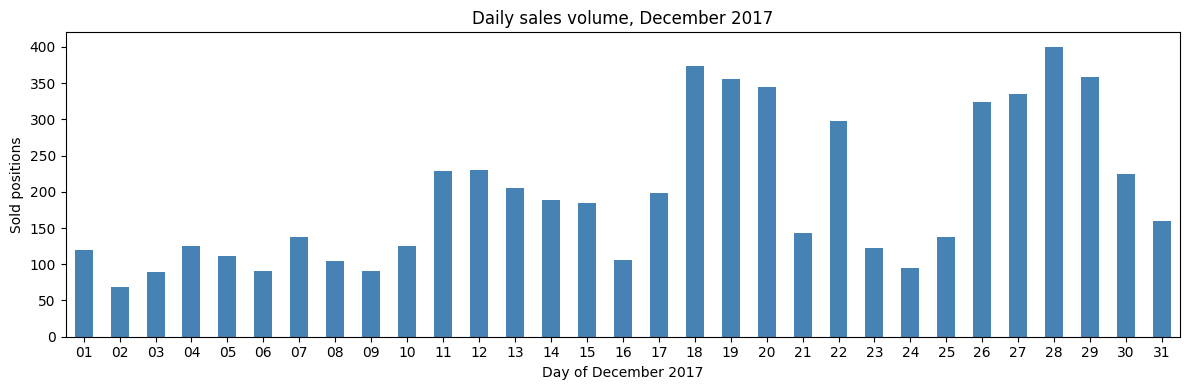

In [14]:
december = analysis_df.resample("D", on="date").size().loc["2017-12"]

december.index = december.index.strftime("%d")
december.plot(kind="bar", figsize=(12,4), color="steelblue")
plt.xlabel("Day of December 2017")
plt.ylabel("Sold positions")
plt.title("Daily sales volume, December 2017")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
analysis_df.resample("D", on="date")["discount_pct"].mean().loc["2017-12"].round(1)

,discount_pct
date,
2017-12-01,18.40
2017-12-02,19.30
2017-12-03,18.00
2017-12-04,14.00
2017-12-05,15.10
2017-12-06,17.10
2017-12-07,16.60
2017-12-08,16.50
2017-12-09,15.70


### Findings

**Black Friday dominates the year.** 24 November is the strongest single day
by a wide margin (1,849 positions), with volume building from 20 November and
a second peak on 27 November (Cyber Monday).

**Christmas peaks after the holiday, not before.** The strongest day in December
is the 28th. Post-holiday trading (26–29 Dec) outperforms the pre-Christmas period.
Discounts in that period stay around 22%, close to the annual average — the rise
comes from demand, not from clearance pricing.

**November and December carry the year.** Both months run at roughly twice the
baseline volume of an average month.

**Seasonal peaks are driven by demand and calendar events, not by deeper discounting.**

## 10. Do discounts drive sales volume?

This is the core question behind the project. Marketing argues discounts drive
growth; the board suspects they erode revenue.

Each product is aggregated to its average discount and total units sold across
the full period. If discounting worked as a volume driver, products with higher
discounts should sell more.

In [16]:
per_sku = analysis_df.groupby("sku").agg(
    avg_discount=("discount_pct", "mean"),
    units=("product_quantity", "sum")
)
per_sku = per_sku[per_sku["avg_discount"].between(0, 80)]

per_sku["avg_discount"].corr(per_sku["units"]).round(3)

np.float64(-0.002)

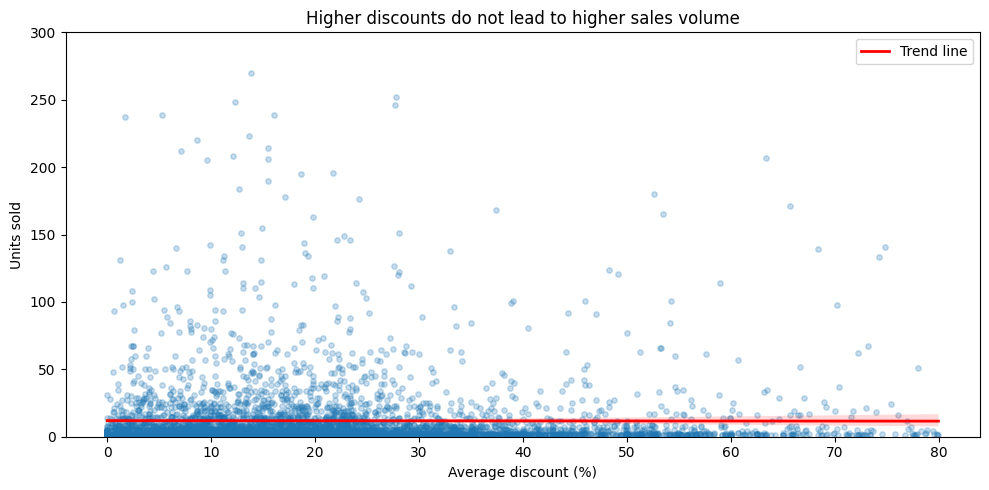

In [17]:
plt.figure(figsize=(10,5))
sns.regplot(data=per_sku, x="avg_discount", y="units",
            scatter_kws={"alpha":0.25, "s":15},
            line_kws={"color":"red", "linewidth":2, "label":"Trend line"})
plt.ylim(0, 300)
plt.xlabel("Average discount (%)")
plt.ylabel("Units sold")
plt.title("Higher discounts do not lead to higher sales volume")
plt.legend()
plt.tight_layout()
plt.show()

### Findings

The trend line is flat. Products discounted at 5% and products discounted at 50%
sell comparable quantities, and the best-selling items are spread across the whole
discount range rather than concentrated at the high end.

If discounting drove volume, the cloud would slope upward to the right. It does not.

**No measurable relationship between discount depth and units sold.**

*Limitation: these are observational data. Since 91.6% of all sales are discounted,
there is no meaningful control group. A causal effect could only be established
through controlled testing.*

### Are peak days driven by deeper discounts?

The seasonal analysis showed volume spikes on Black Friday and after Christmas.
If discounting caused those spikes, discount levels should be markedly higher
on those days.

In [18]:
peak_days = ["2017-11-23", "2017-11-24", "2017-11-27", "2017-12-18", "2017-12-28"]
analysis_df["is_peak"] = analysis_df["date"].dt.strftime("%Y-%m-%d").isin(peak_days)

analysis_df.groupby("is_peak").agg(
    avg_discount=("discount_pct", "mean"),
    median_discount=("discount_pct", "median"),
    positions=("sku", "count")
).round(1)

,avg_discount,median_discount,positions
is_peak,,,
False,21.30,17.40,48538
True,22.60,20.80,4693


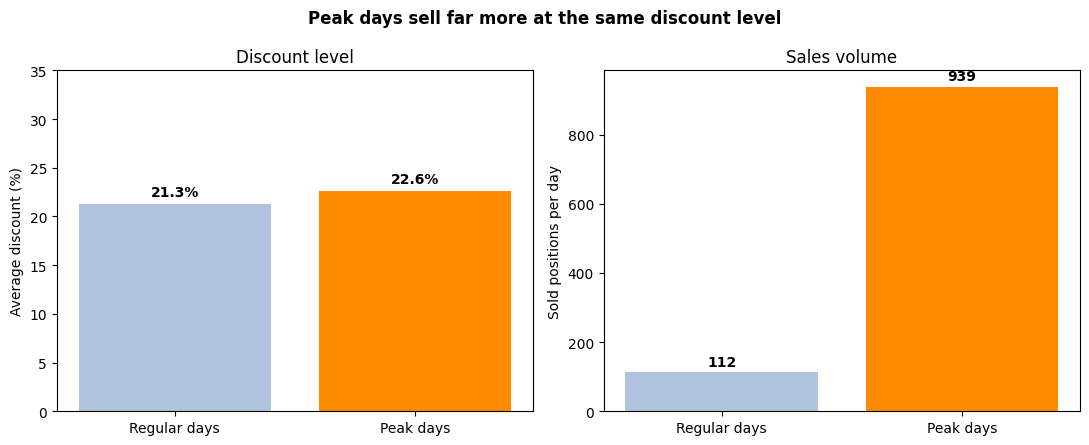

In [19]:
peak_days = ["2017-11-23", "2017-11-24", "2017-11-27", "2017-12-18", "2017-12-28"]
analysis_df["is_peak"] = analysis_df["date"].dt.strftime("%Y-%m-%d").isin(peak_days)

comparison = analysis_df.groupby("is_peak").agg(
    avg_discount=("discount_pct", "mean"),
    positions=("sku", "count")
).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# links: Rabatt
ax1.bar(["Regular days", "Peak days"], comparison["avg_discount"],
        color=["lightsteelblue", "darkorange"])
ax1.set_ylabel("Average discount (%)")
ax1.set_title("Discount level")
ax1.set_ylim(0, 35)
for i, v in enumerate(comparison["avg_discount"]):
    ax1.text(i, v + 0.8, f"{v}%", ha="center", fontweight="bold")

# rechts: Volumen pro Tag
days_regular = 438 - len(peak_days)
per_day = [comparison["positions"].iloc[0] / days_regular,
           comparison["positions"].iloc[1] / len(peak_days)]

ax2.bar(["Regular days", "Peak days"], per_day,
        color=["lightsteelblue", "darkorange"])
ax2.set_ylabel("Sold positions per day")
ax2.set_title("Sales volume")
for i, v in enumerate(per_day):
    ax2.text(i, v + max(per_day)*0.02, f"{v:.0f}", ha="center", fontweight="bold")

plt.suptitle("Peak days sell far more at the same discount level", fontweight="bold")
plt.tight_layout()
plt.show()

Discount levels on peak days are in line with the rest of the year.
Customers buy more on these dates without being offered better prices.

**Demand, not discounting, explains the peaks.**

## 12. How should products be classified into categories?

The product table has no category field. Three sources were considered:

- **`type`** — numeric codes with no documentation. Groupings exist, but their
  meaning cannot be verified, so they were not used.
- **SKU prefix** — the first three characters identify the brand (`APP` = Apple,
  `KIN` = Kingston). A useful second dimension, but not a product category.
- **Product names** — the source used here.

Rather than reading through thousands of product names, all names were split into
individual words and counted. The most frequent terms revealed the natural
categories in the catalogue:

`case` (1,947) · `ram` (1,209) · `ssd` (1,062) · `usb` (805) · `nas` (648)

These keywords were turned into rule-based categories using regular expressions.
Accessory rules were applied before device rules, so that an "Apple iPhone Case"
is classified as a case rather than a smartphone.

In [20]:
woerter = products["name"].str.lower().str.split(expand=True).stack()
woerter.value_counts().head(50)

,count
|,3893
apple,2618
iphone,1956
case,1947
/,1921
pro,1764
-,1480
black,1264
macbook,1221
ram,1209


## 13. What is the price distribution across categories?

Prices span several orders of magnitude — from cables under €10 to laptops
above €2,000 — so the y-axis is logarithmic.

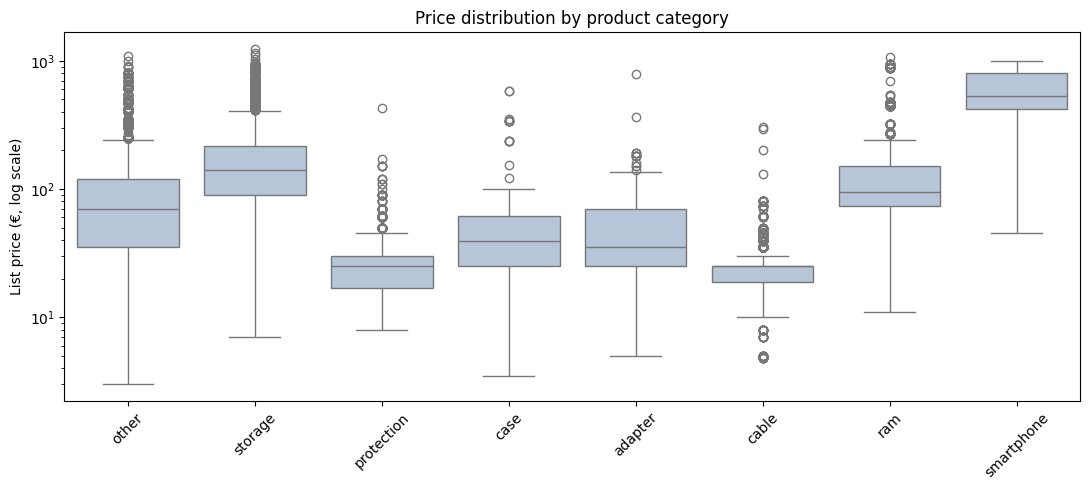

In [21]:
top_cats = analysis_df["category"].value_counts().head(8).index
sub = analysis_df[analysis_df["category"].isin(top_cats)]

plt.figure(figsize=(11,5))
sns.boxplot(data=sub, x="category", y="price", color="lightsteelblue")
plt.yscale("log")
plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("List price (€, log scale)")
plt.title("Price distribution by product category")
plt.tight_layout()
plt.show()

In [22]:
sub.groupby("category").agg(
    median_price=("price", "median"),
    median_discount=("discount_pct", "median"),
    positions=("sku", "count")
).round(1).sort_values("median_price", ascending=False)

,median_price,median_discount,positions
category,,,
smartphone,529.00,5.00,1886
storage,140.00,16.70,8110
ram,94.00,14.10,2762
other,70.00,19.00,7122
case,39.00,28.60,2065
adapter,35.00,15.20,1916
cable,25.00,31.50,1956
protection,25.00,23.50,2488


Discount levels are broadly similar across categories, regardless of price level.
Eniac applies a uniform discount policy rather than differentiating by product type.

## 14. How could data collection be improved?

Roughly two thirds of the product catalogue had to be excluded before analysis
could begin. The issues found are structural, not one-off errors.

**1. Price fields are unreliable**
`promo_price` was corrupted in ~92% of rows and had to be dropped entirely.
`price` contained malformed values such as "304.223.23" or "179.903" — no
consistent corruption rule could be reverse-engineered, so affected rows were removed.

**2. No price history**
`products.price` holds a single current value, while `unit_price` reflects the
price at time of sale. For products with falling prices this produces negative
discounts. Prices should be stored with validity dates so discounts can be
calculated against the list price that applied at the time.

**3. Data gap in February–March 2017**
Order volume drops from ~120 to under 10 per day on 23 February and stays low
for weeks — in both `orders` and `orderlines`. The cause cannot be determined
from the data and requires clarification with the database team.

**4. Dead and undocumented columns**
`product_id` contains only zeros across all rows. `type` holds numeric codes
with no documented meaning.

**5. Inventory is a snapshot without quantities**
`in_stock` holds only 0/1 for a single point in time. It cannot be determined
whether low sales reflect low demand or products simply being unavailable.

**6. Encoding errors in product names**
Corrupted characters appear in the catalogue, e.g. "DDR3åÊ1333MhzåÊ".

**Every finding in this analysis rests on the remaining third of the catalogue.
Fixing the price fields and adding price history would have the largest impact
on future analyses.**

**Bonus: Significant data gap in March**

Text(0, 0.5, 'Order lines per day')

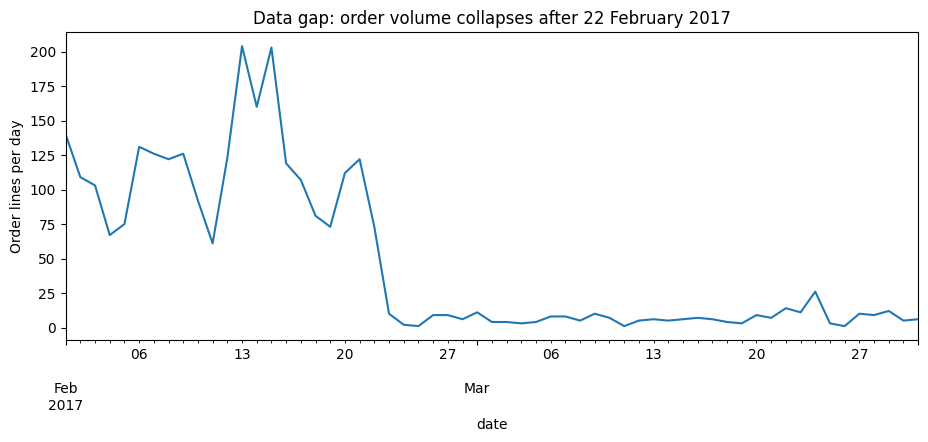

In [23]:
orderlines.resample("D", on="date").size().loc["2017-02":"2017-03"].plot(figsize=(11,4))
plt.title("Data gap: order volume collapses after 22 February 2017")
plt.ylabel("Order lines per day")

## Conclusion

**Discounting at Eniac is not a strategy — it is the default state.**
91.6% of all sold positions were discounted, at a median of 17.7%. The list
price is largely theoretical.

**No measurable link between discount depth and sales.** Products discounted
at 5% and at 50% sell comparable quantities. Monthly revenue shows no
relationship to monthly discount levels.

**Seasonal peaks are demand-driven.** Black Friday and the post-Christmas period
produce the year's highest volumes at discount levels in line with the annual average.

**The board's concern is not supported by the data.** Order volume and revenue
move together; there is no period where more orders coincided with falling revenue.

**Recommendation:** The effect of discounting cannot be established from
observational data alone — 91.6% discount coverage leaves no control group.
A controlled test on selected products would be required to measure whether
discounts pay for themselves.